# Minnesota Sustainability Index (MPCA / GreenStep) — extract & clean

Builds one **tidy long table of documents** from the five thematic worksheet exports of the Minnesota Sustainability Index: one row per community-document, with a generic `document_type` / `document_label` / `document_year` / `document_url` shape instead of a column per artifact. Source and license: see the review README one level up (`../../README.md`). Originating need: `2026-07-mn-city-ghgi`.

Restart-and-run-all must pass. Each cleaning block implements exactly one parsing note from the README; each validation is an assertion, not an eyeball.

## 1. Load raw

Read the five worksheets exactly as they sit on disk, zero transformations. They carry a `.csv` extension but are UTF-16 little-endian, tab-separated (README parsing note 1) — a naive comma read fails.

In [1]:
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 60, "display.width", 220)
DATA = Path("data")

WORKSHEETS = {
    "planning":    "Planning WS.csv",
    "ghg":         "GHG and Climate Mitigation WS.csv",
    "vuln":        "Vulnerability and Equity WS.csv",
    "commitments": "Formal Commitments WS.csv",
    "greenteams":  "Green Teams and Commissions WS.csv",
}

raw = {k: pd.read_csv(DATA / v, encoding="utf-16", sep="\t") for k, v in WORKSHEETS.items()}
pd.DataFrame({"worksheet": list(raw), "rows": [len(d) for d in raw.values()],
              "cols": [d.shape[1] for d in raw.values()],
              "unique_communities": [d["Community Name"].nunique() for d in raw.values()]})

,worksheet,rows,cols,unique_communities
0,planning,292,17,73
1,ghg,476,14,119
2,vuln,114,8,38
3,commitments,300,12,60
4,greenteams,410,12,82


## 2. Clean

### 2a. Dedupe helper — first non-blank per community (README parsing note 2)

Each community appears as several duplicate rows (4 in Planning/GHG, 3 in Vulnerability, 5 in Commitments/Green Teams): a denormalization artifact where different attributes land on different rows. Collapse to one row per community by taking the first non-blank value per field. Blank means "not logged", so blanks are skipped rather than overwriting a real value.

In [2]:
def blank(series):
    return series.isna() | (series.astype(str).str.strip() == "")

def first_nonblank(series):
    s = series[~blank(series)]
    return s.iloc[0] if len(s) else pd.NA

def dedupe(df):
    return df.groupby("Community Name", sort=False).agg(first_nonblank).reset_index()

deduped = {k: dedupe(v) for k, v in raw.items()}
pd.DataFrame({"worksheet": list(deduped),
              "rows_after_dedupe": [len(d) for d in deduped.values()]})

,worksheet,rows_after_dedupe
0,planning,73
1,ghg,119
2,vuln,38
3,commitments,60
4,greenteams,82


### 2b. Authoritative community type (README parsing note 4)

`Type of Community` sits on only some of a community's rows and some worksheets, so recover it with the same first-non-blank rule across all five sources. The earlier hand-built master left `type` blank for 23 communities whose type is present in the worksheets; this map fixes that and is attached to every document row.

In [3]:
type_long = pd.concat([raw[k][["Community Name", "Type of Community"]] for k in raw], ignore_index=True)
type_long["Type of Community"] = type_long["Type of Community"].where(~blank(type_long["Type of Community"]))
type_map = (type_long.dropna(subset=["Type of Community"])
            .groupby("Community Name")["Type of Community"].first())
type_map.value_counts()

Type of Community
City             147
Region             9
Tribal Nation      6
County             6
Watershed          2
Township           1
State              1
Name: count, dtype: int64

### 2c. Reshape to one row per document (README parsing note 3)

The presence columns are not `Yes`/`No`; a populated cell holds the resource's label (for the GHG inventory, values such as "Twin Cities GHG Inventory" or "RII"). Presence = non-blank. Rather than a wide column-per-artifact table, emit one tidy row per present document, keyed by a controlled `document_type` vocabulary. A document's optional free-text name goes in `document_label` (GHG-inventory provider, formal-commitment name), its adoption year in `document_year`, and its link in `document_url`. Absence of a document is simply the absence of a row.

In [4]:
def col(df, name):
    return df[name] if name in df.columns else pd.Series(pd.NA, index=df.index)

def emit(df, document_type, present_col, url_col=None, year_col=None, label_col=None):
    """One row per community where present_col is non-blank."""
    keep = ~blank(df[present_col])
    d = df.loc[keep]
    out = pd.DataFrame({
        "community":      d["Community Name"],
        "document_type":  document_type,
        "document_label": (d[label_col] if label_col else pd.NA),
        "document_year":  (col(d, year_col) if year_col else pd.NA),
        "document_url":   (col(d, url_col) if url_col else pd.NA),
    })
    return out

p, g, v, t = deduped["planning"], deduped["ghg"], deduped["vuln"], deduped["greenteams"]

parts = [
    emit(p, "climate_action_plan",            "Climate Action Plan",
         url_col="Climate Action Plan Website", year_col="Climate Action Plan Year"),
    emit(p, "energy_action_plan",             "Energy Action Plan",
         url_col="Energy Action Plan Website", year_col="Energy Action Plan Year"),
    emit(p, "adaptation_resiliency_plan",     "Adaptation/Resiliency Plan",
         url_col="Adaptation/Resiliency Plan Website"),
    emit(g, "ghg_inventory",                  "Community-wide GHG Inventory",
         url_col="Community-wide GHG Inventory Website", label_col="Community-wide GHG Inventory"),
    emit(g, "ghg_reduction_goal",             "Community GHG reduction goal",
         url_col="Community-wide GHG emissions reduction goal website",
         year_col="Community-wide GHG emissions reduction goal year"),
    emit(v, "vulnerability_risk_assessment",  "Vulnerability/Risk Assessment (infrastructure)",
         url_col="Vulnerability Risk Assessment Website"),
    emit(v, "vulnerable_population_assessment","Vulnerable Population Assessment",
         url_col="Vulnerable Population Assessment Website"),
    emit(v, "equity_plan",                    "Equity Planning/Action Plan",
         url_col="Equity Planning/Action Plan website"),
    emit(t, "environmental_sustainability_commission", "Environmental/Sustainability Commission",
         url_col="Environmental/Sustainability Commission website"),
    emit(t, "equity_human_rights_commission", "Equity/Human Rights Commission",
         url_col="Equity/Human Rights Commission website"),
    emit(t, "green_team_community_led",       "Green Team (community-led - residents)",
         url_col="Green Team - community led - website"),
    emit(t, "green_team_internal_staff",      "Green Team (internal - staff)",
         url_col="Green Team - internal - staff - website"),
    emit(t, "green_team_joint",               "Green Team (joint - staff and community)",
         url_col="Green Team joint - staff and community website"),
]

# Formal commitments: one row per named commitment the community holds.
c = deduped["commitments"]
COMMITMENTS = {
    "Cities Race to Zero": "Cities Race to Zero Website",
    "Climate Emergency Declaration": "Climate Emergency Declaration website",
    "Climate Mayors": "Climate Mayors website",
    "U.S. Conference of Mayors' Climate Protection Agreement": "US Mayors Climate website",
    "We Are Still In": "We Are Still In website",
}
for name, web in COMMITMENTS.items():
    d = c.loc[~blank(c[name])]
    parts.append(pd.DataFrame({
        "community":      d["Community Name"],
        "document_type":  "formal_commitment",
        "document_label": name,
        "document_year":  pd.NA,
        "document_url":   col(d, web),
    }))

documents = pd.concat(parts, ignore_index=True)

# Tidy up: attach type, normalise blanks/whitespace, coerce year to nullable Int, order.
documents.insert(1, "type", documents["community"].map(type_map))
for c_ in ["document_label", "document_url"]:
    documents[c_] = documents[c_].where(~blank(documents[c_])).astype("string").str.strip()
documents["document_year"] = pd.to_numeric(documents["document_year"], errors="coerce").astype("Int64")
documents = (documents[["community", "type", "document_type", "document_label", "document_year", "document_url"]]
             .sort_values(["community", "document_type"]).reset_index(drop=True))
documents.head(12)

,community,type,document_type,document_label,document_year,document_url
0,Afton,City,ghg_inventory,Twin Cities GHG Inventory,<NA>,https://metrocouncil.org/tcghginventory.aspx
1,Akeley,City,adaptation_resiliency_plan,<NA>,<NA>,https://palebluedot.llc/akeley-minnesota-clima...
2,Akeley,City,vulnerable_population_assessment,<NA>,<NA>,https://palebluedot.llc/akeley-minnesota-clima...
3,Albert Lea,City,adaptation_resiliency_plan,<NA>,<NA>,https://palebluedot.llc/albert-lea-minnesota-c...
4,Albert Lea,City,climate_action_plan,<NA>,2021,https://palebluedot.llc/albert-lea-cap
5,Albert Lea,City,equity_human_rights_commission,<NA>,<NA>,https://cityofalbertlea.org/boards-and-commiss...
6,Albert Lea,City,ghg_inventory,RII,<NA>,https://www.regionalindicatorsmn.com/city-summary
7,Albert Lea,City,ghg_reduction_goal,<NA>,2021,https://palebluedot.llc/albert-lea-cap
8,Albert Lea,City,green_team_internal_staff,<NA>,<NA>,https://www.cityofalbertlea.org/about-albert-l...
9,Albert Lea,City,vulnerable_population_assessment,<NA>,<NA>,https://palebluedot.llc/albert-lea-minnesota-c...


## 3. Validate

Assertions, not eyeballing. Per-`document_type` row counts against the profiled worksheet truth, every row carries a repaired `type`, no duplicate community-document rows, and the known Energy-plan quirk pinned both ways so it cannot silently drift.

In [5]:
EXPECTED = {
    "climate_action_plan": 17, "energy_action_plan": 44, "adaptation_resiliency_plan": 37,
    "ghg_inventory": 113, "ghg_reduction_goal": 35,
    "vulnerability_risk_assessment": 5, "vulnerable_population_assessment": 32, "equity_plan": 9,
    "formal_commitment": 91,
    "environmental_sustainability_commission": 40, "equity_human_rights_commission": 30,
    "green_team_community_led": 6, "green_team_internal_staff": 25, "green_team_joint": 14,
}
got = documents["document_type"].value_counts().to_dict()
for k, exp in EXPECTED.items():
    assert got.get(k, 0) == exp, (k, got.get(k, 0), exp)

# key identity: no duplicate (community, document_type) except the intentionally repeatable formal_commitment
dup = documents[documents["document_type"] != "formal_commitment"].duplicated(["community", "document_type"]).sum()
assert dup == 0, dup

# type repaired on every row, only expected admin types
assert documents["type"].notna().all()
assert set(documents["type"].unique()) <= {"City", "County", "Region", "State", "Township",
                                           "Tribal Nation", "Watershed"}, set(documents["type"].unique())

# total rows, and communities that have at least one document
assert len(documents) == 498, len(documents)

# Energy-plan quirk (README interpretation warning): 44 rows by the named-plan flag;
# Minneapolis carries an energy URL+year with no flag, so any-field coverage is 45.
energy_rows = (documents["document_type"] == "energy_action_plan").sum()
energy_any = deduped["planning"]
energy_any = ((~blank(energy_any["Energy Action Plan"]))
              | (~blank(energy_any["Energy Action Plan Website"]))
              | (~blank(energy_any["Energy Action Plan Year"]))).sum()
assert energy_rows == 44 and energy_any == 45, (energy_rows, energy_any)

print("all assertions passed")
print(f"{len(documents)} document rows across {documents['community'].nunique()} communities")
print(f"energy plans: {energy_rows} by named-plan flag, {energy_any} by any-energy-field")

all assertions passed
498 document rows across 172 communities
energy plans: 44 by named-plan flag, 45 by any-energy-field


## 4. Export

One committed, pipeline-ready table: the tidy documents table replaces the earlier wide master. Six columns instead of twenty-two, one row per community-document.

In [ ]:
out = DATA / "mn_sustainability_index_documents.csv"
documents.to_csv(out, index=False)
print("wrote", out, documents.shape)
documents.sample(8, random_state=0).sort_values(["community", "document_type"])

wrote data/mn_sustainability_index_documents_2026-07.csv (498, 6)


,community,type,document_type,document_label,document_year,document_url
15,Arden Hills,City,ghg_inventory,Twin Cities GHG Inventory,<NA>,https://metrocouncil.org/tcghginventory.aspx
90,Detroit Lakes,City,green_team_joint,<NA>,<NA>,<NA>
254,Metropolitan Council,Region,vulnerable_population_assessment,<NA>,<NA>,https://metrocouncil.org/Communities/Planning/...
283,Minnetonka,City,ghg_reduction_goal,<NA>,2024,https://ehq-production-us-california.s3.us-wes...
316,Northfield,City,ghg_reduction_goal,<NA>,2019,https://ci.northfield.mn.us/DocumentCenter/Vie...
336,Prairie Island Indian Community,Tribal Nation,green_team_joint,<NA>,<NA>,<NA>
443,Silver Bay,City,ghg_inventory,RII,<NA>,https://www.regionalindicatorsmn.com/city-summary
487,Winona,City,environmental_sustainability_commission,<NA>,<NA>,https://www.cityofwinona.com/294/Citizens-Envi...


## 5. Visualise & fit

Charts render inline here only (no image files are written); the review's tables carry the precise numbers. The wide, one-row-per-city view any consumer wants is a pivot away, shown first. Two fit questions follow from the `2026-07-mn-city-ghgi` need: city-only coverage, and the cities carrying the CAP + GHG-inventory + vulnerability-assessment trio the CNB seeds a cohort city from.

In [7]:
import matplotlib.pyplot as plt

# The long table pivots trivially to the familiar one-row-per-community presence matrix.
presence = (documents.assign(present=1)
            .pivot_table(index=["community", "type"], columns="document_type",
                         values="present", aggfunc="max", fill_value=0))
print("pivot shape (communities with >=1 document x document types):", presence.shape)
presence.head()

pivot shape (communities with >=1 document x document types): (172, 14)


,document_type,adaptation_resiliency_plan,climate_action_plan,energy_action_plan,environmental_sustainability_commission,equity_human_rights_commission,equity_plan,formal_commitment,ghg_inventory,ghg_reduction_goal,green_team_community_led,green_team_internal_staff,green_team_joint,vulnerability_risk_assessment,vulnerable_population_assessment
community,type,,,,,,,,,,,,,,
Afton,City,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Akeley,City,1,0,0,0,0,0,0,0,0,0,0,0,0,1
Albert Lea,City,1,1,0,0,1,0,0,1,1,0,1,0,0,1
Andover,City,0,0,0,0,0,0,0,1,0,0,0,0,0,0
Anoka,City,0,0,0,0,1,0,0,1,0,0,0,0,0,0


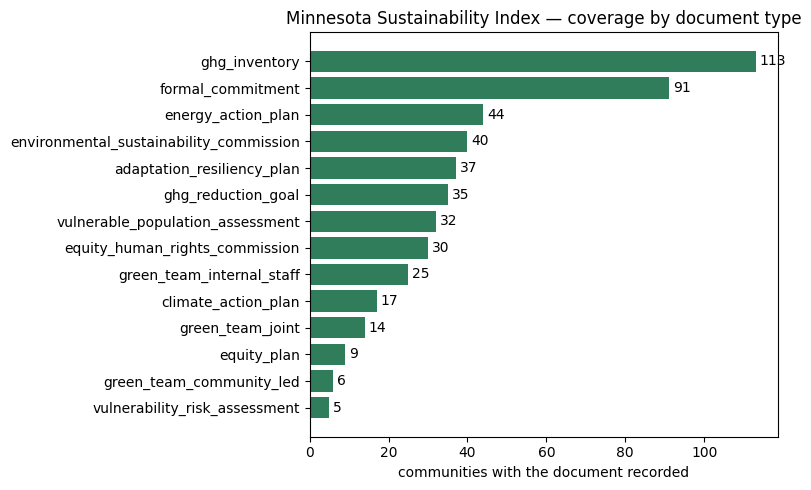

In [8]:
counts = documents["document_type"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(counts.index, counts.values, color="#2f7d5b")
ax.set_xlabel("communities with the document recorded")
ax.set_title("Minnesota Sustainability Index — coverage by document type")
for i, val in enumerate(counts.values):
    ax.text(val + 1, i, str(val), va="center")
plt.tight_layout(); plt.show()

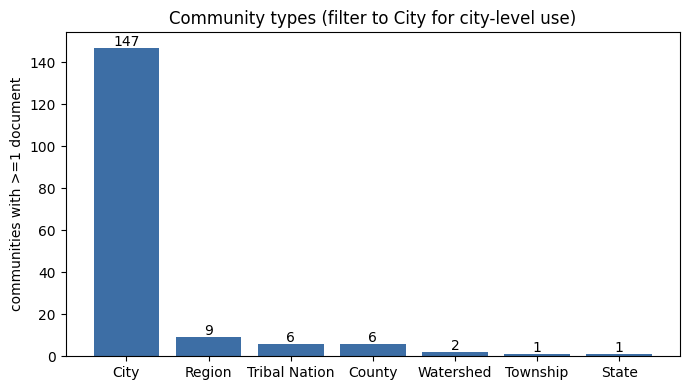

type
City             147
Region             9
Tribal Nation      6
County             6
Watershed          2
Township           1
State              1
Name: count, dtype: int64

In [9]:
type_counts = documents.drop_duplicates("community")["type"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(type_counts.index, type_counts.values, color="#3d6ea5")
ax.set_ylabel("communities with >=1 document"); ax.set_title("Community types (filter to City for city-level use)")
for i, val in enumerate(type_counts.values):
    ax.text(i, val + 1, str(val), ha="center")
plt.tight_layout(); plt.show()
type_counts

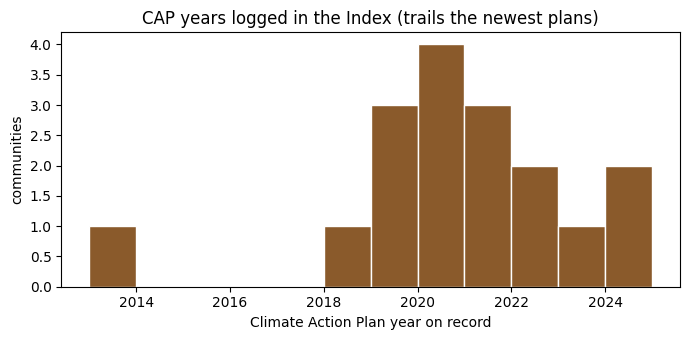

count      17.000000
mean     2020.352941
std         2.572479
min      2013.000000
25%      2019.000000
50%      2020.000000
75%      2022.000000
max      2024.000000
Name: document_year, dtype: float64

In [10]:
years = documents.loc[documents["document_type"] == "climate_action_plan", "document_year"].dropna().astype(int)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(years, bins=range(years.min(), years.max() + 2), color="#8a5a2b", edgecolor="white")
ax.set_xlabel("Climate Action Plan year on record"); ax.set_ylabel("communities")
ax.set_title("CAP years logged in the Index (trails the newest plans)")
plt.tight_layout(); plt.show()
years.describe()

In [11]:
# Fit cell 1 — city-only coverage
city_docs = documents[documents["type"] == "City"]
n_cities = city_docs["community"].nunique()
fit = (city_docs["document_type"].value_counts()
       .reindex(["climate_action_plan", "ghg_inventory", "ghg_reduction_goal",
                 "vulnerable_population_assessment", "adaptation_resiliency_plan"])
       .rename("cities_with").to_frame())
fit["of_cities_with_any_doc"] = n_cities
fit

,cities_with,of_cities_with_any_doc
document_type,,
climate_action_plan,13,147
ghg_inventory,112,147
ghg_reduction_goal,30,147
vulnerable_population_assessment,21,147
adaptation_resiliency_plan,23,147


In [12]:
# Fit cell 2 — cities carrying the full CNB seed trio (CAP + GHG inventory + a vulnerability assessment)
def has(df, dt):
    return set(df.loc[df["document_type"] == dt, "community"])
cap = has(city_docs, "climate_action_plan")
inv = has(city_docs, "ghg_inventory")
vuln = has(city_docs, "vulnerable_population_assessment") | has(city_docs, "vulnerability_risk_assessment")
trio = sorted(cap & inv & vuln)
print(f"{len(trio)} cities carry CAP + GHG inventory + a vulnerability assessment:")
trio

8 cities carry CAP + GHG inventory + a vulnerability assessment:


['Albert Lea',
 'Burnsville',
 'Duluth',
 'Edina',
 'Minneapolis',
 'Minnetonka',
 'Saint Louis Park',
 'Saint Paul']

## 6. Findings

The reshape to a long documents table preserves every signal in the earlier wide master while cutting the schema from twenty-two columns to six. Each artifact becomes one row keyed by a controlled `document_type`; the wide presence matrix any consumer wants is one `pivot_table` away (block 5). Per-type counts reproduce the profiled truth exactly (17 CAPs, 44 energy plans, 37 adaptation plans, 113 GHG inventories, 35 GHG goals, 5 infrastructure and 32 vulnerable-population assessments, 9 equity plans, 91 commitment rows across 60 communities, and the five green-team/commission bodies), for 498 document rows.

Going long also surfaced detail the wide master had folded away. Formal commitments are now one row per named commitment with its own link, so a community's several commitments are no longer a semicolon-joined string. The green-team flag is likewise unpacked into its five distinct bodies, so the Environmental/Sustainability Commission (40), Equity/Human Rights Commission (30), and the three Green Team types (6 / 25 / 14) are separable rather than collapsed into a single `green_team_or_commission` count; the old "74" is now a group-by over the four green/sustainability bodies.

Two facts flowed back into the README. The earlier master left `type` blank for 23 communities although the type is present in the worksheets; the type map here repairs it, so every document row carries a type. And the Energy Action Plan count is genuinely ambiguous: 44 rows by the named-plan flag, but Minneapolis carries an energy URL and 1996 year with no flag, so an any-field count is 45. The table emits the flag-based 44 and the assertion pins both numbers. The city-only fit cells show the directory is usable for cohort seeding: GHG-inventory coverage is near-universal among cities, and eight cities carry the full CAP + inventory + vulnerability-assessment trio.